# Furniture product image-text sample

Build a reproducible sample of 20,000 furniture products from the Amazon Home & Kitchen metadata. A product is furniture only when its taxonomy begins with `Home & Kitchen > Furniture`. Eligible products must have a unique product ID, a non-empty description, and a primary image URL.

In [1]:
from pathlib import Path
import csv
import gzip
import json
import random

from IPython.display import Image, display
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SOURCE_PATH = PROJECT_ROOT / "full_metadata" / "meta_Home_and_Kitchen.jsonl.gz"
SAMPLE_PATH = PROJECT_ROOT / "data" / "meta_Home_and_Kitchen_furniture_sample_20k.csv"
IMAGE_DIR = PROJECT_ROOT / "data" / "images_furniture"
IMAGE_MANIFEST_PATH = PROJECT_ROOT / "data" / "meta_Home_and_Kitchen_furniture_images_20k.csv"
IMAGE_FAILURES_PATH = PROJECT_ROOT / "data" / "meta_Home_and_Kitchen_furniture_image_failures_20k.csv"
SIGLIP2_PAIRS_PATH = PROJECT_ROOT / "data" / "meta_Home_and_Kitchen_furniture_siglip2_pairs_20k.csv"

SAMPLE_SIZE = 20_000
RANDOM_SEED = 42
MAX_WORKERS = 24

assert SOURCE_PATH.exists(), f"Missing source metadata: {SOURCE_PATH}"
SOURCE_PATH, SAMPLE_PATH, IMAGE_DIR

(PosixPath('/Users/vachemacbook/Desktop/RecSystem/RecSystem/full_metadata/meta_Home_and_Kitchen.jsonl.gz'),
 PosixPath('/Users/vachemacbook/Desktop/RecSystem/RecSystem/data/meta_Home_and_Kitchen_furniture_sample_20k.csv'),
 PosixPath('/Users/vachemacbook/Desktop/RecSystem/RecSystem/data/images_furniture'))

In [2]:
def is_furniture_record(record):
    categories = record.get("categories") or []
    return (
        len(categories) >= 2
        and str(categories[0]).strip() == "Home & Kitchen"
        and str(categories[1]).strip() == "Furniture"
    )


def normalize_furniture_product(record):
    if not is_furniture_record(record):
        return None

    descriptions = record.get("description") or []
    if isinstance(descriptions, str):
        descriptions = [descriptions]
    description = " ".join(
        part.strip() for part in descriptions if isinstance(part, str) and part.strip()
    )

    images = record.get("images") or []
    primary = next(
        (image for image in images if isinstance(image, dict) and image.get("variant") == "MAIN"),
        images[0] if images and isinstance(images[0], dict) else {},
    )
    image_url = primary.get("large") or primary.get("hi_res") or primary.get("thumb")
    image_url_high_res = primary.get("hi_res") or primary.get("large") or primary.get("thumb")

    categories = [str(value).strip() for value in (record.get("categories") or [])]
    product = {
        "asin": record.get("parent_asin") or record.get("asin"),
        "description": description,
        "image_url": image_url,
        "image_url_high_res": image_url_high_res,
        "furniture_subcategory": categories[2] if len(categories) > 2 else "Unspecified",
        "category_path": " > ".join(categories),
    }
    return product if product["asin"] and description and image_url else None


def reservoir_sample_furniture(path, sample_size=20_000, seed=42):
    rng = random.Random(seed)
    sample = []
    eligible_count = 0
    seen_asins = set()

    with gzip.open(path, "rt", encoding="utf-8") as source:
        for line_number, line in enumerate(source, start=1):
            product = normalize_furniture_product(json.loads(line))
            if product is None or product["asin"] in seen_asins:
                continue

            seen_asins.add(product["asin"])
            eligible_count += 1
            if len(sample) < sample_size:
                sample.append(product)
            else:
                replacement_index = rng.randrange(eligible_count)
                if replacement_index < sample_size:
                    sample[replacement_index] = product

            if line_number % 500_000 == 0:
                print(f"Read {line_number:,} products; {eligible_count:,} unique eligible furniture products")

    if eligible_count < sample_size:
        raise ValueError(f"Requested {sample_size:,} rows, but only {eligible_count:,} were eligible")
    return sample, eligible_count

In [3]:
sample_columns = [
    "asin",
    "description",
    "image_url",
    "image_url_high_res",
    "furniture_subcategory",
    "category_path",
]

if SAMPLE_PATH.exists():
    sample_df = pd.read_csv(SAMPLE_PATH)
    missing_columns = set(sample_columns) - set(sample_df.columns)
    assert not missing_columns, f"Existing sample is missing columns: {sorted(missing_columns)}"
    assert len(sample_df) == SAMPLE_SIZE, (
        f"Expected {SAMPLE_SIZE:,} rows in existing sample, found {len(sample_df):,}"
    )
    assert sample_df["asin"].is_unique, "Existing sample contains duplicate ASINs"
    print(f"Using existing validated sample: {SAMPLE_PATH}")
else:
    products, eligible_count = reservoir_sample_furniture(SOURCE_PATH, SAMPLE_SIZE, RANDOM_SEED)
    SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with SAMPLE_PATH.open("w", newline="", encoding="utf-8") as output:
        writer = csv.DictWriter(output, fieldnames=sample_columns)
        writer.writeheader()
        writer.writerows(products)
    sample_df = pd.DataFrame(products, columns=sample_columns)
    print(
        f"Saved {len(sample_df):,} sampled products from {eligible_count:,} "
        f"unique eligible furniture products to {SAMPLE_PATH}"
    )

Using existing validated sample: /Users/vachemacbook/Desktop/RecSystem/RecSystem/data/meta_Home_and_Kitchen_furniture_sample_20k.csv


In [4]:
print(f"Rows: {len(sample_df):,}")
print(f"Unique ASINs: {sample_df['asin'].nunique():,}")
print("\nFurniture subcategory distribution:")
display(sample_df["furniture_subcategory"].value_counts().rename_axis("subcategory").to_frame("products"))
display(sample_df.head(10))

for row in sample_df.head(5).itertuples():
    print(f"{row.asin} | {row.furniture_subcategory}: {row.description[:250]}")
    display(Image(url=row.image_url, width=250))

Rows: 20,000
Unique ASINs: 20,000

Furniture subcategory distribution:


,products
subcategory,
Living Room Furniture,6949
Bedroom Furniture,4087
Home Office Furniture,2335
Dining Room Furniture,2046
Game & Recreation Room Furniture,1963
Kids' Furniture,833
Unspecified,522
Entryway Furniture,389
Accent Furniture,365


,asin,description,image_url,image_url_high_res,furniture_subcategory,category_path
0,B018NZJ75M,"Offer a warm, inviting look to your kitchen, d...",https://m.media-amazon.com/images/I/310YsdOsBt...,https://m.media-amazon.com/images/I/514ji+koZw...,Game & Recreation Room Furniture,Home & Kitchen > Furniture > Game & Recreation...
1,B082XWFB66,Inspired by the playful style of the Italian M...,https://m.media-amazon.com/images/I/51vYt-zYCm...,https://m.media-amazon.com/images/I/81WSLgqOXY...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B0892Q8NLR,Featuring classic design elements and plentifu...,https://m.media-amazon.com/images/I/41wtcqgNo0...,https://m.media-amazon.com/images/I/71OtRyAwXC...,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...
3,B08D67VZFH,"Features: Made of premium birch, solid constru...",https://m.media-amazon.com/images/I/41Xu5s1EYk...,https://m.media-amazon.com/images/I/51Jjoe3j7Z...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B0B35BM8RQ,"The 1.5-inch Bunkie Board , Split Bunkie Board...",https://m.media-amazon.com/images/I/21nqEG68Ke...,https://m.media-amazon.com/images/I/61uwH2zQr9...,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...
5,B07V4PVRV1,Give your table a makeover with a new glass to...,https://m.media-amazon.com/images/I/21pfRKIbc7...,https://m.media-amazon.com/images/I/51xGrWpHvZ...,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
6,B0088XR2WK,"Embracing a contemporary, youthful approach to...",https://m.media-amazon.com/images/I/41NZO5Govm...,https://m.media-amazon.com/images/I/41NZO5Govm...,Game & Recreation Room Furniture,Home & Kitchen > Furniture > Game & Recreation...
7,B00BUY3AC0,The ultra handy and handsome perth espresso ov...,https://m.media-amazon.com/images/I/515FvTCC4O...,https://m.media-amazon.com/images/I/61mz9eR7ls...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
8,B00BQK2SN0,This Stanis circular end table is made of maho...,https://m.media-amazon.com/images/I/41RNM8Z5-m...,https://m.media-amazon.com/images/I/71PfcVyKUR...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
9,B00IECZHNQ,The Shape Chair has won various design prizes ...,https://m.media-amazon.com/images/I/41TxBdRe6F...,https://m.media-amazon.com/images/I/51ah+fLYaq...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...


B018NZJ75M | Game & Recreation Room Furniture: Offer a warm, inviting look to your kitchen, dining room, bar, or lounge with this solid wood barstool from International Concepts. This beautifully crafted stool is part of a high-quality collection of wood furniture that boosts a traditional and el


B082XWFB66 | Living Room Furniture: Inspired by the playful style of the Italian Memphis movement, this brilliant crème ottoman in PU leather will adds instant warmth and character to any modern space. Polished stainless steel legs make it a contemporary classic.


B0892Q8NLR | Bedroom Furniture: Featuring classic design elements and plentiful storage space, the Riko bed is quintessential for the modern bedroom. Made in Malaysia, this wooden bed is fitted with multiple storage compartments at the headboard and underneath the platform. Inset p


B08D67VZFH | Living Room Furniture: Features: Made of premium birch, solid construction, good load-bearing capacity, sturdy and durable. Ergonomic designed curve suits human being structure perfectly, providing maximum comfort. The cushion is soft and elastic,easy to install to the cha


B0B35BM8RQ | Bedroom Furniture: The 1.5-inch Bunkie Board , Split Bunkie Board provides a surface foundation for any platform beds, bunks and daybeds. It adds support to the mattress and will keep mattress stay in good shape thus extending the life of your mattress. It will give a 


## Download the 20,000 furniture images

Download one primary image for every sampled ASIN into `data/images_furniture`. The operation is resumable: existing valid files are skipped, downloads are retried, and any remaining failures are written to a separate CSV.

In [5]:
from concurrent.futures import ThreadPoolExecutor
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen
import time

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
EXISTING_IMAGE_PATHS = {
    path.stem: path
    for path in IMAGE_DIR.iterdir()
    if path.is_file() and not path.name.endswith(".part") and path.stat().st_size > 0
}


def image_extension(content):
    if content.startswith(b"\xff\xd8\xff"):
        return ".jpg"
    if content.startswith(b"\x89PNG\r\n\x1a\n"):
        return ".png"
    if content[:4] == b"RIFF" and content[8:12] == b"WEBP":
        return ".webp"
    if content.startswith((b"GIF87a", b"GIF89a")):
        return ".gif"
    raise ValueError("Response is not a supported image")


def download_product_image(row, attempts=3):
    asin = row.asin
    existing = EXISTING_IMAGE_PATHS.get(str(asin))
    if existing:
        return {
            "asin": asin,
            "image_url": row.image_url,
            "image_path": str(existing.relative_to(PROJECT_ROOT)),
            "error": "",
        }

    urls = list(dict.fromkeys(url for url in (row.image_url, row.image_url_high_res) if pd.notna(url)))
    last_error = "No image URL"
    for url in urls:
        for attempt in range(1, attempts + 1):
            try:
                request = Request(str(url), headers={"User-Agent": "Mozilla/5.0"})
                with urlopen(request, timeout=30) as response:
                    content = response.read()
                suffix = image_extension(content)
                destination = IMAGE_DIR / f"{asin}{suffix}"
                temporary = destination.with_suffix(destination.suffix + ".part")
                temporary.write_bytes(content)
                temporary.replace(destination)
                EXISTING_IMAGE_PATHS[str(asin)] = destination
                return {
                    "asin": asin,
                    "image_url": str(url),
                    "image_path": str(destination.relative_to(PROJECT_ROOT)),
                    "error": "",
                }
            except (HTTPError, URLError, TimeoutError, ValueError, OSError) as exc:
                last_error = f"{type(exc).__name__}: {exc}"
                if attempt < attempts:
                    time.sleep(attempt)

    return {"asin": asin, "image_url": row.image_url, "image_path": "", "error": last_error}


def find_replacement_products(path, excluded_asins, candidate_limit):
    replacements = []
    with gzip.open(path, "rt", encoding="utf-8") as source:
        for line in source:
            product = normalize_furniture_product(json.loads(line))
            if product is None or product["asin"] in excluded_asins:
                continue
            replacements.append(product)
            excluded_asins.add(product["asin"])
            if len(replacements) >= candidate_limit:
                break
    return replacements


records = list(sample_df[["asin", "image_url", "image_url_high_res"]].itertuples(index=False))
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    download_results = []
    for completed, result in enumerate(executor.map(download_product_image, records), start=1):
        download_results.append(result)
        if completed % 1_000 == 0 or completed == len(records):
            failures_so_far = sum(bool(item["error"]) for item in download_results)
            print(f"Processed {completed:,}/{len(records):,}; failures so far: {failures_so_far:,}")

results_df = pd.DataFrame(download_results)
image_manifest_df = results_df.loc[
    results_df.error.eq(""), ["asin", "image_url", "image_path"]
].copy()
failures_df = results_df.loc[
    results_df.error.ne(""), ["asin", "image_url", "error"]
].copy()

# Replace exhausted downloads so the final sample still contains exactly 20,000 usable pairs.
if not failures_df.empty:
    needed = len(failures_df)
    failed_sample_asins = set(failures_df["asin"])
    replacement_candidates = find_replacement_products(
        SOURCE_PATH,
        excluded_asins=set(sample_df["asin"]),
        candidate_limit=max(needed * 20, 100),
    )
    successful_products = []
    successful_results = []
    replacement_failures = []

    for product in replacement_candidates:
        row = next(
            pd.DataFrame([product])[["asin", "image_url", "image_url_high_res"]]
            .itertuples(index=False)
        )
        result = download_product_image(row)
        if result["error"]:
            replacement_failures.append(result)
            continue
        successful_products.append(product)
        successful_results.append(result)
        if len(successful_products) == needed:
            break

    if len(successful_products) < needed:
        raise RuntimeError(
            f"Needed {needed:,} replacements but downloaded only {len(successful_products):,}"
        )

    sample_df = pd.concat(
        [
            sample_df.loc[~sample_df["asin"].isin(failed_sample_asins)],
            pd.DataFrame(successful_products),
        ],
        ignore_index=True,
    )
    image_manifest_df = pd.concat(
        [image_manifest_df, pd.DataFrame(successful_results)[["asin", "image_url", "image_path"]]],
        ignore_index=True,
    )
    if replacement_failures:
        failures_df = pd.concat(
            [failures_df, pd.DataFrame(replacement_failures)[["asin", "image_url", "error"]]],
            ignore_index=True,
        )
    print(f"Backfilled {len(successful_products):,} failed sample downloads")

assert len(sample_df) == SAMPLE_SIZE
assert sample_df["asin"].is_unique
assert len(image_manifest_df) == SAMPLE_SIZE
sample_df.to_csv(SAMPLE_PATH, index=False, columns=sample_columns)
image_manifest_df.to_csv(IMAGE_MANIFEST_PATH, index=False)
failures_df.to_csv(IMAGE_FAILURES_PATH, index=False)
print(f"Final downloaded sample: {len(image_manifest_df):,} / {SAMPLE_SIZE:,}")
print(f"Exhausted source URLs recorded: {len(failures_df):,}")

Processed 1,000/20,000; failures so far: 0
Processed 2,000/20,000; failures so far: 0
Processed 3,000/20,000; failures so far: 0
Processed 4,000/20,000; failures so far: 0
Processed 5,000/20,000; failures so far: 0
Processed 6,000/20,000; failures so far: 0
Processed 7,000/20,000; failures so far: 0
Processed 8,000/20,000; failures so far: 0
Processed 9,000/20,000; failures so far: 0
Processed 10,000/20,000; failures so far: 0
Processed 11,000/20,000; failures so far: 0
Processed 12,000/20,000; failures so far: 0


Processed 13,000/20,000; failures so far: 1
Processed 14,000/20,000; failures so far: 1
Processed 15,000/20,000; failures so far: 1
Processed 16,000/20,000; failures so far: 1
Processed 17,000/20,000; failures so far: 1
Processed 18,000/20,000; failures so far: 1
Processed 19,000/20,000; failures so far: 1
Processed 20,000/20,000; failures so far: 1


Backfilled 1 failed sample downloads


Final downloaded sample: 20,000 / 20,000
Exhausted source URLs recorded: 1


Sampled products: 20,000
Usable image-text pairs: 20,000
Saved pairs to: /Users/vachemacbook/Desktop/RecSystem/RecSystem/data/meta_Home_and_Kitchen_furniture_siglip2_pairs_20k.csv


,asin,description,furniture_subcategory,category_path,image_path
0,B018NZJ75M,"Offer a warm, inviting look to your kitchen, d...",Game & Recreation Room Furniture,Home & Kitchen > Furniture > Game & Recreation...,data/images_furniture/B018NZJ75M.jpg
1,B082XWFB66,Inspired by the playful style of the Italian M...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...,data/images_furniture/B082XWFB66.jpg
2,B0892Q8NLR,Featuring classic design elements and plentifu...,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...,data/images_furniture/B0892Q8NLR.jpg
3,B08D67VZFH,"Features: Made of premium birch, solid constru...",Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...,data/images_furniture/B08D67VZFH.jpg
4,B0B35BM8RQ,"The 1.5-inch Bunkie Board , Split Bunkie Board...",Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...,data/images_furniture/B0B35BM8RQ.jpg
5,B07V4PVRV1,Give your table a makeover with a new glass to...,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...,data/images_furniture/B07V4PVRV1.jpg
6,B0088XR2WK,"Embracing a contemporary, youthful approach to...",Game & Recreation Room Furniture,Home & Kitchen > Furniture > Game & Recreation...,data/images_furniture/B0088XR2WK.jpg
7,B00BUY3AC0,The ultra handy and handsome perth espresso ov...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...,data/images_furniture/B00BUY3AC0.jpg
8,B00BQK2SN0,This Stanis circular end table is made of maho...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...,data/images_furniture/B00BQK2SN0.jpg
9,B00IECZHNQ,The Shape Chair has won various design prizes ...,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...,data/images_furniture/B00IECZHNQ.jpg


B018NZJ75M | Game & Recreation Room Furniture: Offer a warm, inviting look to your kitchen, dining room, bar, or lounge with this solid wood barstool from International Concepts. This beautifully crafted stool is part of a high-quality collection of wood furniture that boosts a traditional and el


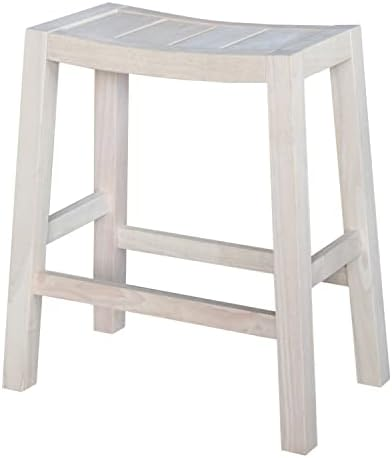

B082XWFB66 | Living Room Furniture: Inspired by the playful style of the Italian Memphis movement, this brilliant crème ottoman in PU leather will adds instant warmth and character to any modern space. Polished stainless steel legs make it a contemporary classic.


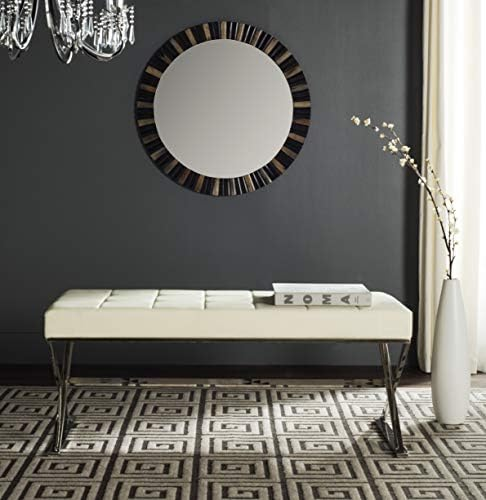

B0892Q8NLR | Bedroom Furniture: Featuring classic design elements and plentiful storage space, the Riko bed is quintessential for the modern bedroom. Made in Malaysia, this wooden bed is fitted with multiple storage compartments at the headboard and underneath the platform. Inset p


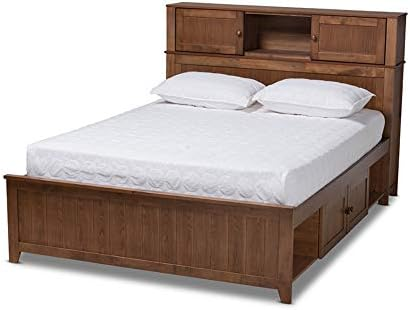

B08D67VZFH | Living Room Furniture: Features: Made of premium birch, solid construction, good load-bearing capacity, sturdy and durable. Ergonomic designed curve suits human being structure perfectly, providing maximum comfort. The cushion is soft and elastic,easy to install to the cha


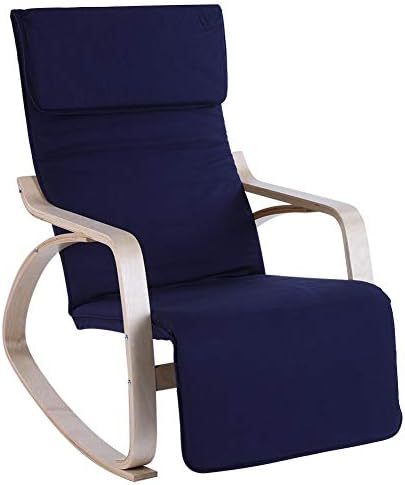

B0B35BM8RQ | Bedroom Furniture: The 1.5-inch Bunkie Board , Split Bunkie Board provides a surface foundation for any platform beds, bunks and daybeds. It adds support to the mattress and will keep mattress stay in good shape thus extending the life of your mattress. It will give a 


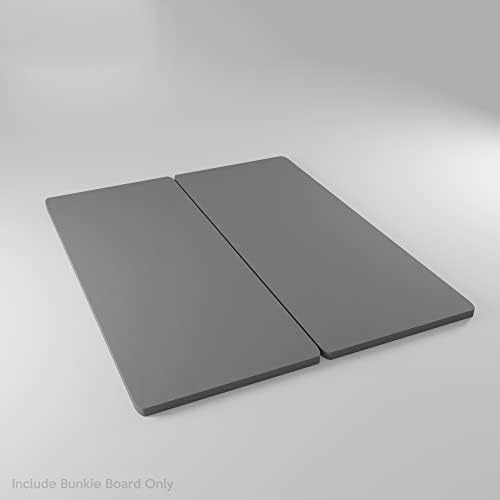

In [6]:
# SigLIP2-ready rows retain product ID, description, taxonomy, and the local image path.
siglip2_df = sample_df[["asin", "description", "furniture_subcategory", "category_path"]].merge(
    image_manifest_df[["asin", "image_path"]],
    on="asin",
    how="inner",
    validate="one_to_one",
)
siglip2_df.to_csv(SIGLIP2_PAIRS_PATH, index=False)

assert sample_df["asin"].is_unique
assert siglip2_df["asin"].is_unique
assert siglip2_df[["asin", "description", "image_path"]].notna().all().all()
missing_local_images = [
    path for path in siglip2_df["image_path"] if not (PROJECT_ROOT / path).is_file()
]
assert not missing_local_images, f"Missing {len(missing_local_images):,} local images"

print(f"Sampled products: {len(sample_df):,}")
print(f"Usable image-text pairs: {len(siglip2_df):,}")
print(f"Saved pairs to: {SIGLIP2_PAIRS_PATH}")
display(siglip2_df.head(10))

for row in siglip2_df.head(5).itertuples():
    print(f"{row.asin} | {row.furniture_subcategory}: {row.description[:250]}")
    display(Image(filename=str(PROJECT_ROOT / row.image_path), width=250))